# 05_FusionInference — 노이즈 종류별 이미지 단위 예측

노이즈 이미지 1장 + 해당 시점을 끝으로 하는 센서 윈도우를 융합해 이상 확률 예측.  
오토인코더 복원 오차를 가중치로 변환해 노이즈 수준이 높을수록 이미지 신뢰도를 낮춤.

```
final_prob = W_IMG × p_img + W_SENSOR × p_sensor
W_IMG = clip(1 - normalized_recon_error, 0, 1)
```

| 노이즈 종류 | 설명 |
|---|---|
| full_mixed | 모든 노이즈 혼합 |
| fume_smoke | 연기/흄 노이즈 |
| vibration  | 진동 블러 노이즈 |

In [12]:
from pathlib import Path

# ── 경로 ──────────────────────────────────────────────────────────
BASE_DIR       = Path.home() / 'Desktop' / 'ai1' / 'noise_target'
NOISE_PIC_DIR  = BASE_DIR / 'noise_pic' / 'noise_selected'
SENSOR_DIR     = BASE_DIR / 'original_INC_202501'
LABEL_TXT      = SENSOR_DIR / 'label_mapping.txt'
MOBILENET_PATH = BASE_DIR / 'best_mobilenet.pth'
RNN_PATH       = BASE_DIR / 'best_rnn.pt'
AUTOENC_PATH   = BASE_DIR / 'autoencoder_split_rgb.pth'

# ── 센서 설정 ─────────────────────────────────────────────────────
FEATURES      = ['Avg Voltage', 'Avg Current']
WINDOW_SIZE   = 30
SENSOR_HZ     = 10
VAL_TRIAL_IDS = {44, 45}

# ── 이미지 설정 (MobileNetV2) ─────────────────────────────────────
MOBILENET_IMG_SIZE = 224

# ── 오토인코더 설정 ───────────────────────────────────────────────
AE_IMG_SIZE = 256
LATENT_DIM  = 512

# ── 기타 ──────────────────────────────────────────────────────────
# AE_ERROR_MAX : 모델 로드 후 검은 이미지 복원 오차로 자동 결정 (fu_004 이후)
THRESHOLD   = 0.5
RANDOM_SEED = 42

import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

Device : cuda


In [13]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, average_precision_score,
                              f1_score, precision_score, recall_score)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# 노이즈 종류 자동 탐색
NOISE_TYPES = sorted({
    d.name
    for trial_dir in NOISE_PIC_DIR.iterdir() if trial_dir.is_dir()
    for d in trial_dir.iterdir() if d.is_dir()
})
print(f'탐색된 노이즈 종류: {NOISE_TYPES}')
print('임포트 완료')

탐색된 노이즈 종류: ['full_mixed', 'fume_smoke', 'vibration']
임포트 완료


In [14]:
# =========================
# 모델 정의 및 로드
# =========================

# ── MobileNetV2 ───────────────────────────────────────────────────
mobilenet = models.mobilenet_v2(weights=None)
mobilenet.classifier[1] = nn.Linear(mobilenet.last_channel, 2)
mobilenet.load_state_dict(
    torch.load(str(MOBILENET_PATH), map_location=DEVICE, weights_only=True))
mobilenet = mobilenet.to(DEVICE).eval()

mobilenet_tf = transforms.Compose([
    transforms.Resize((MOBILENET_IMG_SIZE, MOBILENET_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

@torch.no_grad()
def predict_image(img_path):
    """이미지 1장 → 이상 확률 softmax[:, 1]"""
    img = mobilenet_tf(Image.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
    return float(torch.softmax(mobilenet(img), dim=1)[0, 1].cpu())

print(f'MobileNetV2 로드 완료: {MOBILENET_PATH.name}')

# ── RNN (hidden1=32, hidden2=16, dropout=0.5, n_feat=4) ──────────
class RNNAnomalyDetector(nn.Module):
    def __init__(self, n_features, hidden1, hidden2, dropout):
        super().__init__()
        self.rnn1  = nn.RNN(n_features, hidden1, batch_first=True, nonlinearity='tanh')
        self.drop1 = nn.Dropout(dropout)
        self.rnn2  = nn.RNN(hidden1, hidden2, batch_first=True, nonlinearity='tanh')
        self.drop2 = nn.Dropout(dropout)
        self.fc    = nn.Linear(hidden2, 1)

    def forward(self, x):
        out, _ = self.rnn1(x);  out = self.drop1(out)
        out, _ = self.rnn2(out)
        return torch.sigmoid(self.fc(self.drop2(out[:, -1, :]))).squeeze(-1)

rnn_model = RNNAnomalyDetector(n_features=4, hidden1=32, hidden2=16, dropout=0.5).to(DEVICE)
rnn_model.load_state_dict(
    torch.load(str(RNN_PATH), map_location=DEVICE, weights_only=True))
rnn_model.eval()

@torch.no_grad()
def predict_window(window_np):
    """(30, 4) numpy → 이상 확률 sigmoid 스칼라"""
    x = torch.from_numpy(window_np.astype(np.float32)).unsqueeze(0).to(DEVICE)
    return float(rnn_model(x).cpu())

print(f'RNN 로드 완료: {RNN_PATH.name}')

# ── Autoencoder (RGB 3ch, 256×256) ───────────────────────────────
class Encoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32,  4, 2, 1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32,  64,  4, 2, 1),          nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64,  128, 4, 2, 1),          nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),          nn.BatchNorm2d(256), nn.ReLU(),
        )
        dummy = torch.zeros(1, in_channels, AE_IMG_SIZE, AE_IMG_SIZE)
        fs = self.net(dummy).view(1, -1).shape[1]
        self._flatten_size = fs
        self.fc = nn.Linear(fs, latent_dim)

    def forward(self, x):
        x = self.net(x).view(x.size(0), -1)
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=512, flatten_size=None, spatial=16):
        super().__init__()
        self.spatial = spatial
        self.fc  = nn.Linear(latent_dim, flatten_size)
        self.net = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64,  32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(32, in_channels, 3, padding=1), nn.Tanh(),
        )

    def forward(self, z):
        x = self.fc(z).view(z.size(0), 256, self.spatial, self.spatial)
        return self.net(x)

class Autoencoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=512):
        super().__init__()
        self.encoder = Encoder(in_channels, latent_dim)
        fs = self.encoder._flatten_size
        self.decoder = Decoder(in_channels, latent_dim, fs, int((fs / 256) ** 0.5))

    def forward(self, x):
        return self.decoder(self.encoder(x))

ckpt = torch.load(str(AUTOENC_PATH), map_location=DEVICE, weights_only=False)
ae_model = Autoencoder(in_channels=3, latent_dim=LATENT_DIM).to(DEVICE)
ae_model.load_state_dict(ckpt['model_state_dict'])
ae_model.eval()

ae_tf = transforms.Compose([
    transforms.Resize((AE_IMG_SIZE, AE_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

@torch.no_grad()
def recon_error(img_path):
    """이미지 1장 → 오토인코더 복원 오차 (MSE)"""
    img = ae_tf(Image.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
    rec = ae_model(img)
    return float(((rec - img) ** 2).mean().cpu())

print(f'Autoencoder 로드 완료: {AUTOENC_PATH.name}')

MobileNetV2 로드 완료: best_mobilenet.pth
RNN 로드 완료: best_rnn.pt
Autoencoder 로드 완료: autoencoder_split_rgb.pth


In [15]:
# =========================
# AE_ERROR_MAX 자동 설정: 기준 노이즈 이미지 복원 오차
# 이 이미지의 복원 오차 = noise_level 1.0 기준점
# → 이 이미지와 같거나 더 심한 노이즈 → W_SENSOR=1.0 (센서 100%)
# =========================

@torch.no_grad()
def recon_error_tensor(img_tensor):
    """(1, 3, H, W) 텐서 → 복원 오차 (MSE)"""
    rec = ae_model(img_tensor)
    return float(((rec - img_tensor) ** 2).mean().cpu())

REF_IMG_PATH = (BASE_DIR / 'noise_pic' / 'noise_selected'
                / 'Val8_237A_22TS_200WFR' / 'full_mixed'
                / 'label0_Val8_237A_22TS_200WFR_t0.52s_full_mixed.png')

ref_tensor   = ae_tf(Image.open(REF_IMG_PATH).convert('RGB')).unsqueeze(0).to(DEVICE)
AE_ERROR_MAX = recon_error_tensor(ref_tensor)

print(f'기준 이미지   : {REF_IMG_PATH.name}')
print(f'복원 오차     : {AE_ERROR_MAX:.6f}')
print(f'→ AE_ERROR_MAX = {AE_ERROR_MAX:.6f}  (이 값 이상이면 센서 100%)')

기준 이미지   : label0_Val8_237A_22TS_200WFR_t0.52s_full_mixed.png
복원 오차     : 0.038352
→ AE_ERROR_MAX = 0.038352  (이 값 이상이면 센서 100%)


In [16]:
# =========================
# 센서 데이터 로드 + 글로벌 스케일러
# =========================

def parse_meta(name):
    m = re.search(r'_(\d+)TS_(\d+)WFR', name, re.IGNORECASE)
    return (float(m.group(1)), float(m.group(2))) if m else (None, None)

sensor_data_scaled = {}   # {trial_prefix (e.g.'Val8'): scaled_array (N, 4)}
train_arrays = []

for d in sorted(SENSOR_DIR.iterdir()):
    if not d.is_dir(): continue
    m = re.match(r'^(Test|Val)(\d+)_', d.name, re.IGNORECASE)
    if not m: continue
    ptype, idx = m.group(1).capitalize(), int(m.group(2))
    short = f'{ptype}{idx}'
    ts, wfr = parse_meta(d.name)
    if ts is None: continue
    csvs = list(d.glob('*.csv'))
    if not csvs: continue

    vi = pd.read_csv(csvs[0])[FEATURES].astype(float).values
    mn, sd = vi.mean(0), vi.std(0); sd[sd < 1e-8] = 1e-8
    vi_norm = (vi - mn) / sd
    n = len(vi_norm)
    arr = np.hstack([vi_norm,
                     np.full((n, 1), ts),
                     np.full((n, 1), wfr)]).astype(np.float32)
    sensor_data_scaled[short] = arr  # 임시; 글로벌 스케일 적용 후 교체

    if ptype == 'Test' and idx not in VAL_TRIAL_IDS:
        train_arrays.append(arr)

scaler = StandardScaler().fit(np.vstack(train_arrays).reshape(-1, 4))
sensor_data_scaled = {
    k: scaler.transform(v).astype(np.float32)
    for k, v in sensor_data_scaled.items()
}

print(f'센서 데이터 로드 완료: {len(sensor_data_scaled)}개 trial')

def get_sensor_window(trial_prefix, time_sec):
    """
    time_sec   : 파일명의 t{x}s 값 (초)
    sensor_idx : round(time_sec * SENSOR_HZ)
    window     : arr[sensor_idx-29 : sensor_idx+1]  shape (30, 4)
    샘플 부족(sensor_idx < 29)이면 None 반환 → 스킵
    """
    arr = sensor_data_scaled.get(trial_prefix)
    if arr is None:
        return None
    sensor_idx = min(int(round(time_sec * SENSOR_HZ)), len(arr) - 1)
    if sensor_idx < WINDOW_SIZE - 1:
        return None
    return arr[sensor_idx - WINDOW_SIZE + 1 : sensor_idx + 1].astype(np.float32)

센서 데이터 로드 완료: 19개 trial


In [17]:
# =========================
# 파일 정보 파싱 + 라벨 매핑
# 파일명: label0_Val8_237A_22TS_200WFR_t0.22s_full_mixed.png
# 폴더:   noise_selected/{trial_full}/{noise_type}/
# =========================

label_map = {}
with open(LABEL_TXT, encoding='utf-8') as f:
    for line in f:
        m = re.match(r'^((?:Test|Val)\d+)\S*\s+(\d+)', line.strip())
        if m:
            label_map[m.group(1)] = int(m.group(2))

def parse_noise_image(img_path):
    """
    반환: (trial_prefix, time_sec, noise_type, label)
    예)  label0_Val8_237A_22TS_200WFR_t0.22s_full_mixed.png
         → ('Val8', 0.22, 'full_mixed', 0)
    """
    stem      = img_path.stem
    noise_type = img_path.parent.name          # 폴더명에서 noise_type
    trial_full = img_path.parent.parent.name   # 폴더명에서 trial 전체

    # trial prefix
    mp = re.match(r'^((?:Test|Val))(\d+)', trial_full, re.IGNORECASE)
    if not mp: return None
    trial_prefix = mp.group(1).capitalize() + mp.group(2)

    # label from filename prefix
    ml = re.match(r'^label(\d+)_', stem)
    if not ml: return None
    label = int(ml.group(1))

    # time_sec
    mt = re.search(r'_t(\d+\.?\d*)s_', stem)
    if not mt: return None
    time_sec = float(mt.group(1))

    return trial_prefix, time_sec, noise_type, label

# 파싱 테스트
sample_img = next(NOISE_PIC_DIR.glob('*/*/*.png'), None)
if sample_img:
    print(f'샘플 파일: {sample_img.name}')
    print(f'파싱 결과: {parse_noise_image(sample_img)}')

print(f'\n라벨 매핑: {label_map}')

샘플 파일: label1_Val1_130A_22TS_170WFR_t0.12s_full_mixed.png
파싱 결과: ('Val1', 0.12, 'full_mixed', 1)

라벨 매핑: {'Test1': 0, 'Test2': 0, 'Test3': 0, 'Test5': 0, 'Test7': 0, 'Test8': 0, 'Test31': 1, 'Test32': 1, 'Test34': 1, 'Test38': 1, 'Test41': 1, 'Test43': 1, 'Test44': 0, 'Test45': 1, 'Val1': 1, 'Val2': 1, 'Val5': 0, 'Val8': 0, 'Val9': 0}


In [18]:
# =========================
# 오토인코더 복원 오차 통계 + 가중치 함수
# =========================

all_img_paths = sorted(NOISE_PIC_DIR.glob('*/*/*.png'))
print(f'전체 이미지 수: {len(all_img_paths)}')

# 노이즈 종류별 오차 통계 (참고용)
ae_errors = {}
for img_path in all_img_paths:
    info = parse_noise_image(img_path)
    if info is None: continue
    _, _, noise_type, label = info
    if label not in (0, 1): continue   # label=2(검정화면) 제외
    ae_errors.setdefault(noise_type, []).append(recon_error(img_path))

print(f'\n{"노이즈 종류":15s}  {"n":>5}  {"평균 오차":>12}  {"std":>10}  {"W_IMG평균":>10}')
print('-' * 60)
for nt in NOISE_TYPES:
    errs = ae_errors.get(nt, [])
    if errs:
        w_imgs = [max(0.0, 1.0 - e / AE_ERROR_MAX) for e in errs]
        print(f'{nt:15s}  {len(errs):>5}  {np.mean(errs):>12.6f}'
              f'  {np.std(errs):>10.6f}  {np.mean(w_imgs):>10.4f}')

print(f'\n기준값  AE_ERROR_MAX={AE_ERROR_MAX}'
      f'  →  오차 0일 때 W_IMG=1.0, 오차≥{AE_ERROR_MAX}일 때 W_IMG=0.0')


def get_weights(recon_err):
    """
    noise_level = clip(recon_err / AE_ERROR_MAX, 0, 1)
    W_IMG    = 1 - noise_level
    W_SENSOR = noise_level
    """
    noise_level = float(np.clip(recon_err / AE_ERROR_MAX, 0.0, 1.0))
    return 1.0 - noise_level, noise_level

전체 이미지 수: 4554

노이즈 종류               n         평균 오차         std     W_IMG평균
------------------------------------------------------------
full_mixed        1265      0.031249    0.011747      0.2439
fume_smoke        1432      0.015229    0.007484      0.6063
vibration         1426      0.007732    0.004194      0.7991

기준값  AE_ERROR_MAX=0.03835240751504898  →  오차 0일 때 W_IMG=1.0, 오차≥0.03835240751504898일 때 W_IMG=0.0


In [19]:
# =========================
# 2단계: 노이즈 종류별 이미지 단위 융합 추론
# =========================

def run_experiment(noise_type):
    img_paths = sorted(NOISE_PIC_DIR.glob(f'*/{noise_type}/*.png'))
    rows = []
    skipped_win = skipped_label = 0

    for img_path in img_paths:
        info = parse_noise_image(img_path)
        if info is None: continue
        trial_prefix, time_sec, _, label = info

        if label not in (0, 1):   # label=2(검정화면) 제외
            skipped_label += 1
            continue

        win = get_sensor_window(trial_prefix, time_sec)
        if win is None:
            skipped_win += 1
            continue

        err      = recon_error(img_path)
        p_img    = predict_image(img_path)
        p_sensor = predict_window(win)
        w_i, w_s = get_weights(err)
        p_final  = w_i * p_img + w_s * p_sensor
        pred     = int(p_final >= THRESHOLD)

        rows.append({
            'filename':  img_path.name,
            'trial':     trial_prefix,
            'time_sec':  time_sec,
            'label':     label,
            'ae_error':  round(err,      6),
            'w_img':     round(w_i,      4),
            'w_sensor':  round(w_s,      4),
            'p_img':     round(p_img,    4),
            'p_sensor':  round(p_sensor, 4),
            'p_final':   round(p_final,  4),
            'pred':      pred,
            'correct':   int(pred == label),
        })

    df = pd.DataFrame(rows)
    print(f'[{noise_type}]  처리={len(df)}장  '
          f'스킵(검정화면)={skipped_label}장  스킵(윈도우부족)={skipped_win}장')
    return df


results = {}
for nt in NOISE_TYPES:
    results[nt] = run_experiment(nt)

print('\n실험 완료')

[full_mixed]  처리=1155장  스킵(검정화면)=129장  스킵(윈도우부족)=110장
[fume_smoke]  처리=1308장  스킵(검정화면)=144장  스킵(윈도우부족)=124장
[vibration]  처리=1304장  스킵(검정화면)=158장  스킵(윈도우부족)=122장

실험 완료


In [20]:
# =========================
# 3단계: 노이즈 종류별 평가 출력
# =========================

def evaluate(df, noise_type):
    if len(df) == 0:
        print(f'[{noise_type}] 결과 없음'); return {}
    y_true = df['label'].values
    y_pred = df['pred'].values
    y_prob = df['p_final'].values

    print(f'\n{"="*55}')
    print(f'  [{noise_type}]  n={len(df)}  '
          f'(정상={(y_true==0).sum()}  이상={(y_true==1).sum()})')
    print(f'{"="*55}')
    print(classification_report(y_true, y_pred,
                                 labels=[0, 1],
                                 target_names=['Normal(0)', 'Abnormal(1)'],
                                 zero_division=0))
    metrics = {
        'noise_type':  noise_type,
        'n':           len(df),
        'accuracy':    round((y_true == y_pred).mean(), 4),
        'w_f1':        round(f1_score(y_true, y_pred, labels=[0,1], average='weighted', zero_division=0), 4),
        'precision':   round(precision_score(y_true, y_pred, labels=[0,1], average='weighted', zero_division=0), 4),
        'recall':      round(recall_score(y_true, y_pred, labels=[0,1], average='weighted', zero_division=0), 4),
        'w_img_mean':  round(df['w_img'].mean(), 4),
        'ae_err_mean': round(df['ae_error'].mean(), 6),
    }
    try:
        metrics['roc_auc'] = round(roc_auc_score(y_true, y_prob), 4)
        metrics['pr_auc']  = round(average_precision_score(y_true, y_prob), 4)
    except Exception:
        metrics['roc_auc'] = metrics['pr_auc'] = float('nan')

    print(f"  Accuracy : {metrics['accuracy']:.4f}   ROC-AUC : {metrics['roc_auc']:.4f}")
    print(f"  W_IMG평균: {metrics['w_img_mean']:.4f}  AE오차평균: {metrics['ae_err_mean']:.6f}")
    return metrics

summary = []
for nt in NOISE_TYPES:
    m = evaluate(results[nt], nt)
    if m: summary.append(m)

print('\n\n=== 노이즈 종류별 요약 ===')
summary_df = pd.DataFrame(summary).set_index('noise_type')
print(summary_df[['n','accuracy','w_f1','precision','recall',
                   'roc_auc','pr_auc','w_img_mean','ae_err_mean']].to_string())


  [full_mixed]  n=1155  (정상=620  이상=535)
              precision    recall  f1-score   support

   Normal(0)       0.73      0.92      0.82       620
 Abnormal(1)       0.87      0.60      0.71       535

    accuracy                           0.78      1155
   macro avg       0.80      0.76      0.76      1155
weighted avg       0.80      0.78      0.77      1155

  Accuracy : 0.7758   ROC-AUC : 0.7282
  W_IMG평균: 0.2455  AE오차평균: 0.031180

  [fume_smoke]  n=1308  (정상=773  이상=535)
              precision    recall  f1-score   support

   Normal(0)       0.65      1.00      0.79       773
 Abnormal(1)       0.98      0.22      0.36       535

    accuracy                           0.68      1308
   macro avg       0.82      0.61      0.57      1308
weighted avg       0.78      0.68      0.61      1308

  Accuracy : 0.6781   ROC-AUC : 0.7119
  W_IMG평균: 0.6079  AE오차평균: 0.015175

  [vibration]  n=1304  (정상=769  이상=535)
              precision    recall  f1-score   support

   Normal(0)    

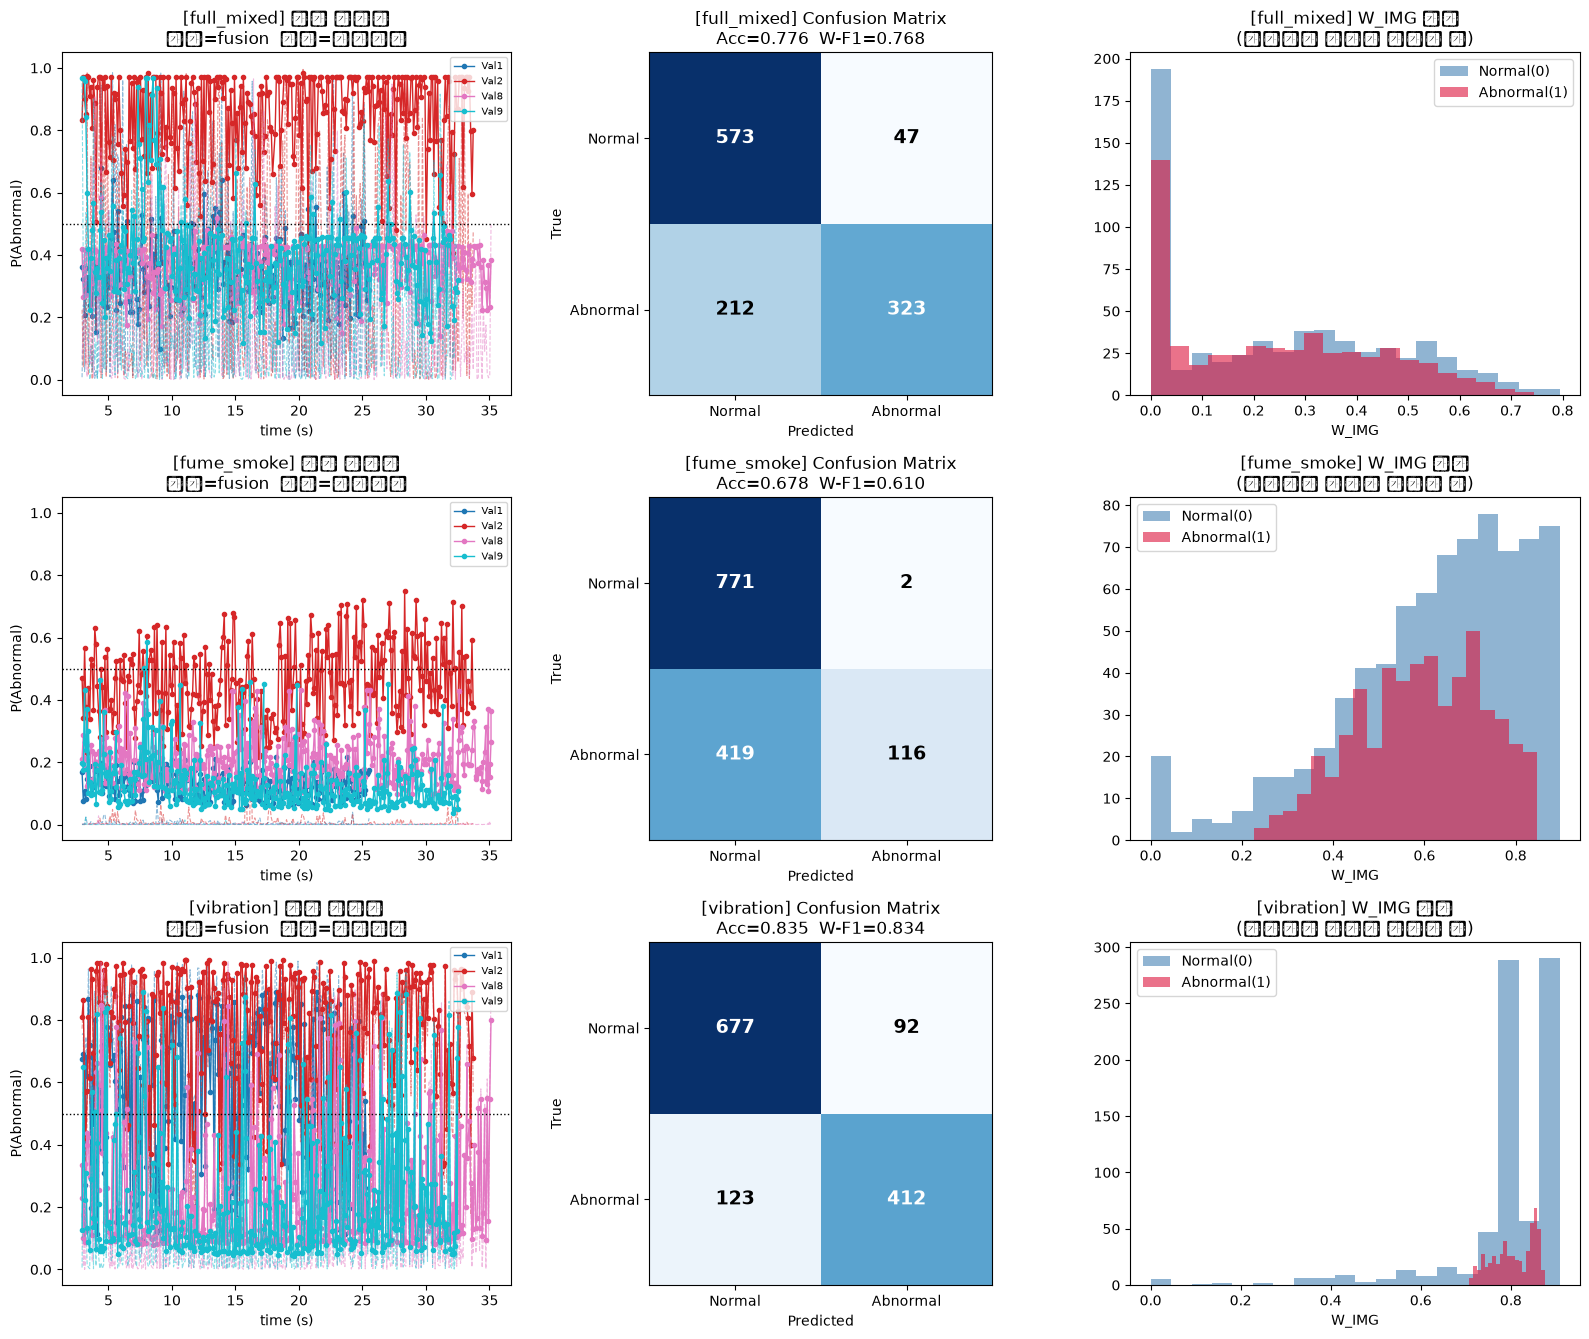

In [21]:
# =========================
# 시각화 — 노이즈 종류별 (행) × [확률 시계열 / 혼동행렬 / W_IMG 분포] (열)
# =========================

n_types = len(NOISE_TYPES)
fig, axes = plt.subplots(n_types, 3, figsize=(16, 4.5 * n_types))
if n_types == 1:
    axes = axes[np.newaxis, :]

for row, nt in enumerate(NOISE_TYPES):
    df = results[nt]
    if len(df) == 0:
        for c in range(3): axes[row, c].set_visible(False)
        continue

    y_true = df['label'].values
    y_pred = df['pred'].values

    # ── 확률 시계열 (trial별 색상) ───────────────────────────────
    ax = axes[row, 0]
    trials  = df['trial'].unique()
    colors  = plt.cm.tab10(np.linspace(0, 1, len(trials)))
    for trial, c in zip(trials, colors):
        grp = df[df['trial'] == trial].sort_values('time_sec')
        ax.plot(grp['time_sec'], grp['p_final'], marker='o', ms=3,
                linewidth=1, color=c, label=trial)
        ax.plot(grp['time_sec'], grp['p_img'],    linestyle='--', lw=0.8,
                color=c, alpha=0.5)
    ax.axhline(THRESHOLD, color='k', linestyle=':', lw=1)
    ax.set_title(f'[{nt}] 확률 시계열\n실선=fusion  점선=이미지만')
    ax.set_xlabel('time (s)'); ax.set_ylabel('P(Abnormal)')
    ax.legend(fontsize=7); ax.set_ylim(-0.05, 1.05)

    # ── 혼동행렬 ─────────────────────────────────────────────────
    ax = axes[row, 1]
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    ax.imshow(cm, cmap='Blues')
    ax.set(xticks=[0,1], yticks=[0,1],
           xticklabels=['Normal','Abnormal'],
           yticklabels=['Normal','Abnormal'],
           xlabel='Predicted', ylabel='True',
           title=f'[{nt}] Confusion Matrix\nAcc={summary_df.loc[nt,"accuracy"]:.3f}  W-F1={summary_df.loc[nt,"w_f1"]:.3f}')
    th = cm.max() / 2
    for i, j in itertools.product(range(2), range(2)):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > th else 'black',
                fontsize=14, fontweight='bold')

    # ── W_IMG 분포 (정상 vs 이상) ────────────────────────────────
    ax = axes[row, 2]
    ax.hist(df[df['label']==0]['w_img'], bins=20, alpha=0.6,
            color='steelblue', label='Normal(0)')
    ax.hist(df[df['label']==1]['w_img'], bins=20, alpha=0.6,
            color='crimson',   label='Abnormal(1)')
    ax.set_title(f'[{nt}] W_IMG 분포\n(낮을수록 이미지 노이즈 큼)')
    ax.set_xlabel('W_IMG'); ax.legend()

plt.tight_layout()
plt.savefig('fusion_noise_types.png', dpi=150)
plt.show()

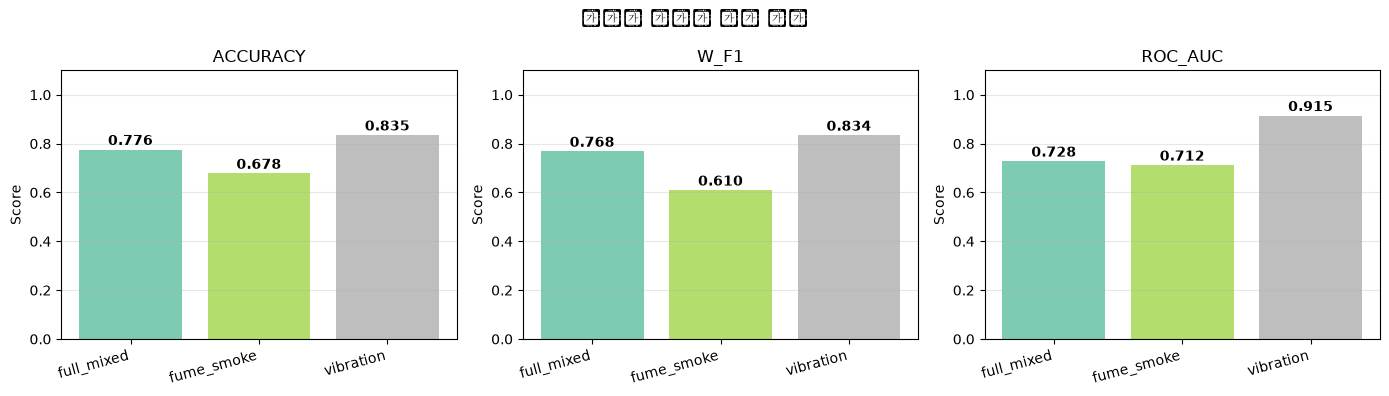


=== 평균 W_IMG (노이즈 종류별) ===
  full_mixed       W_IMG평균=0.2455  AE오차평균=0.031180
  fume_smoke       W_IMG평균=0.6079  AE오차평균=0.015175
  vibration        W_IMG평균=0.8003  AE오차평균=0.007687


In [22]:
# =========================
# 노이즈 종류별 성능 비교 막대 그래프
# =========================

metrics_cols = ['accuracy', 'w_f1', 'roc_auc']
fig, axes = plt.subplots(1, len(metrics_cols), figsize=(14, 4))
colors = plt.cm.Set2(np.linspace(0, 1, len(NOISE_TYPES)))

for ax, col in zip(axes, metrics_cols):
    vals = [summary_df.loc[nt, col] for nt in NOISE_TYPES]
    bars = ax.bar(NOISE_TYPES, vals, color=colors, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_title(col.upper())
    ax.set_ylabel('Score')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

plt.suptitle('노이즈 종류별 성능 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('noise_type_comparison.png', dpi=150)
plt.show()

print('\n=== 평균 W_IMG (노이즈 종류별) ===')
for nt in NOISE_TYPES:
    df = results[nt]
    print(f'  {nt:15s}  W_IMG평균={df["w_img"].mean():.4f}  '
          f'AE오차평균={df["ae_error"].mean():.6f}')